<h1>03 · Entrenamiento del Modelo de Scoring Crediticio <a id="inicio"> </h1>
<em>Notebook desarrollado por Evelyn Cabrera Arias.</em><br><br>

<b>Repositorio:</b> <code>credit-risk-score</code><br>
<b>Modelo:</b> <code>Regresión Logística</code><br>
<b>Objetivo:</b> Entrenar, evaluar y exportar el modelo. Métricas clave: AUC-ROC, KS, matriz de confusión.

<hr>

<h3 style="color: #0d47a1;">Estructura:</h3>

<a href="#seccion-1"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">1. Setup y carga de datos procesados</a>
<a href="#seccion-2"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">2. Entrenamiento del modelo</a>
<a href="#seccion-3"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">3. Métricas de evaluación</a>
<a href="#seccion-4"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">4. Visualizaciones del modelo</a>
<a href="#seccion-5"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">5. Importancia de variables (coeficientes)</a>
<a href="#seccion-6"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">6. Exportar modelo</a>

## 1. Setup y carga de datos procesados <a id="seccion-1"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, roc_auc_score,
                             classification_report, roc_curve)
from scipy.stats import ks_2samp
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

X_train = pd.read_csv('../data/clean/X_train.csv')
X_test  = pd.read_csv('../data/clean/X_test.csv')
y_train = pd.read_csv('../data/clean/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/clean/y_test.csv').squeeze()

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Tasa de mora train: {y_train.mean()*100:.1f}%")

Train: (8000, 20) | Test: (2000, 20)
Tasa de mora train: 20.4%


## 2. Entrenamiento del modelo <a id="seccion-2"></a>

In [2]:
modelo = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',   # clave en scoring crediticio (clases desbalanceadas)
    random_state=42
)
modelo.fit(X_train, y_train)

y_pred  = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

print("✅ Modelo entrenado")
print(f"   Clases: {modelo.classes_}")
print(f"   Iteraciones: {modelo.n_iter_[0]}")

✅ Modelo entrenado
   Clases: [0 1]
   Iteraciones: 34


## 3. Métricas de evaluación <a id="seccion-3"></a>

In [3]:
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['No moroso','Moroso']))

=== Classification Report ===
              precision    recall  f1-score   support

   No moroso       0.91      0.72      0.80      1593
      Moroso       0.39      0.71      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



In [4]:
# AUC-ROC
auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.4f}")
if auc >= 0.75:
    print("✅ Buen poder discriminativo (AUC ≥ 0.75)")
elif auc >= 0.70:
    print("✅ Aceptable (AUC ≥ 0.70)")
else:
    print("⚠️  AUC < 0.70 — revisar variables o modelo")

AUC-ROC: 0.7769
✅ Buen poder discriminativo (AUC ≥ 0.75)


In [5]:
# KS (Kolmogorov-Smirnov)
ks_stat, ks_pvalue = ks_2samp(
    y_proba[y_test == 1],
    y_proba[y_test == 0]
)
print(f"KS Statistic: {ks_stat:.4f}")
print(f"p-value:      {ks_pvalue:.6f}")
if ks_stat >= 0.4:
    print("✅ Buen modelo de scoring (KS ≥ 0.40)")
elif ks_stat >= 0.2:
    print("✅ Modelo aceptable (KS ≥ 0.20)")
else:
    print("⚠️  KS < 0.20 — modelo débil")

KS Statistic: 0.4295
p-value:      0.000000
✅ Buen modelo de scoring (KS ≥ 0.40)


## 4. Visualizaciones del modelo <a id="seccion-4"></a>

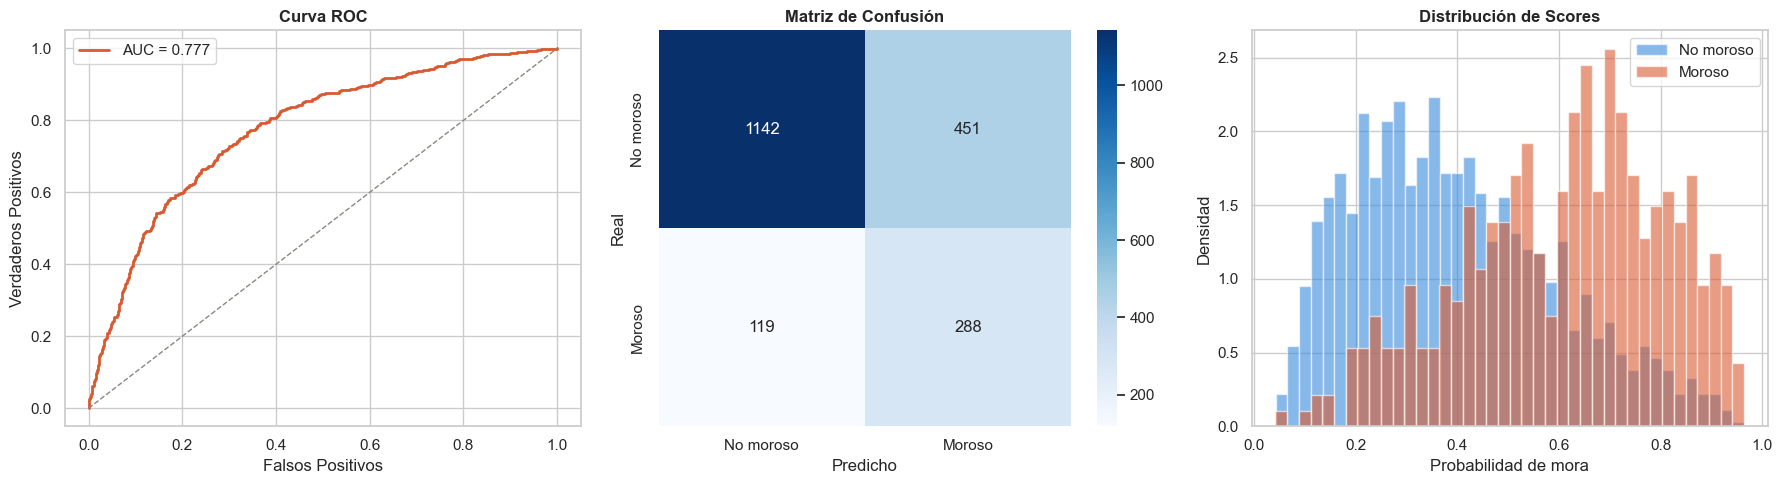

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='#D85A30', lw=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0,1],[0,1], color='#888780', lw=1, linestyle='--')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].set_xlabel('Falsos Positivos')
axes[0].set_ylabel('Verdaderos Positivos')
axes[0].legend()

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No moroso','Moroso'],
            yticklabels=['No moroso','Moroso'])
axes[1].set_title('Matriz de Confusión', fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

# Distribución de scores por clase
axes[2].hist(y_proba[y_test==0], bins=40, alpha=0.6, color='#378ADD', label='No moroso', density=True)
axes[2].hist(y_proba[y_test==1], bins=40, alpha=0.6, color='#D85A30', label='Moroso', density=True)
axes[2].set_title('Distribución de Scores', fontweight='bold')
axes[2].set_xlabel('Probabilidad de mora')
axes[2].set_ylabel('Densidad')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/plots/03_model_evaluation.png', dpi=150)
plt.show()

## 5. Importancia de variables (coeficientes) <a id="seccion-5"></a>

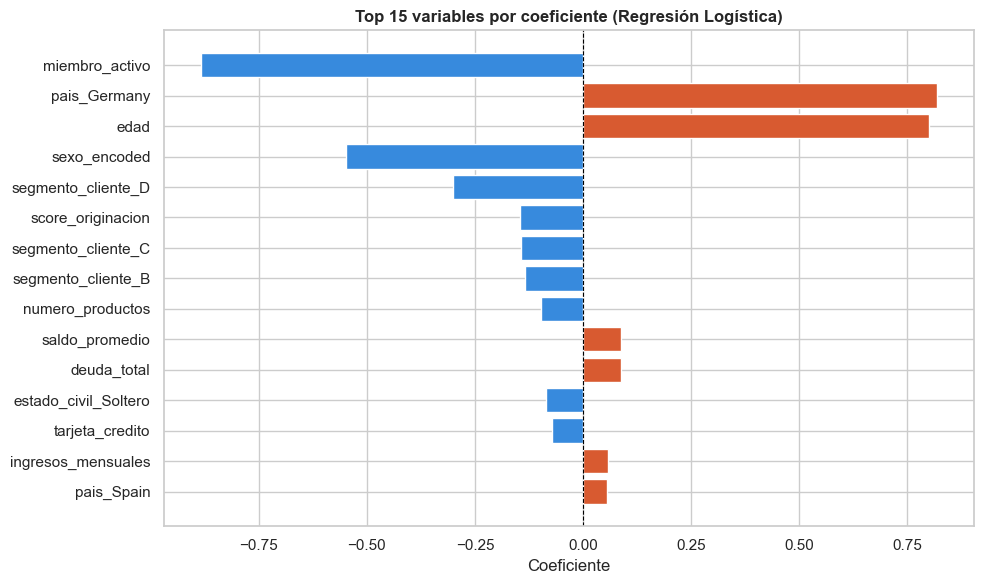

In [7]:
features = joblib.load('../models/features_list.pkl')

coef_df = pd.DataFrame({
    'feature': features,
    'coeficiente': modelo.coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['#D85A30' if c > 0 else '#378ADD' for c in coef_df['coeficiente']]
plt.barh(coef_df['feature'], coef_df['coeficiente'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Top 15 variables por coeficiente (Regresión Logística)', fontweight='bold')
plt.xlabel('Coeficiente')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/plots/03_feature_importance.png', dpi=150)
plt.show()

## 6. Exportar modelo <a id="seccion-6"></a>

In [8]:
joblib.dump(modelo, '../models/logistic_regression_scoring.pkl')
print("✅ Modelo exportado → /models/logistic_regression_scoring.pkl")
print(f"   AUC: {auc:.4f} | KS: {ks_stat:.4f}")

✅ Modelo exportado → /models/logistic_regression_scoring.pkl
   AUC: 0.7769 | KS: 0.4295


<h3 style="color: #0d47a1;">Siguiente paso: </h3>
`04_score_segmentos.ipynb`
<em><a href="#inicio"  style="color:black; text-decoration:underline; display:block; margin:3px 0; font-size:15px;">Volver a inicio de 03_modelo</a></em>